In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import kagglehub

path = kagglehub.dataset_download("atcharachumpol/freshness-fish-dataset")

print("Path to dataset files:", path)

100%|██████████| 405M/405M [00:26<00:00, 16.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/atcharachumpol/freshness-fish-dataset/versions/1


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

# 1. Path to the Atcharachumpol Dataset

dataset_a_path = "/root/.cache/kagglehub/datasets/atcharachumpol/freshness-fish-dataset/versions/1/Freshness Fish Dataset"

# 2. Aggressive Augmentation Pipeline
stream_a_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # MobileNetV2 standard 
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30), # Fish can be placed at any angle on a market table
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.5, hue=0.1), # Confuse the background color
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

# 3. Load the Dataset
try:
    full_dataset_a = datasets.ImageFolder(root=dataset_a_path, transform=stream_a_transforms)

    # 4. Split into Training (80%) and Validation (20%)
    train_size = int(0.8 * len(full_dataset_a))
    val_size = len(full_dataset_a) - train_size
    train_dataset_a, val_dataset_a = random_split(full_dataset_a, [train_size, val_size])

    # 5. Create DataLoaders
    batch_size = 32
    train_loader_a = DataLoader(train_dataset_a, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader_a = DataLoader(val_dataset_a, batch_size=batch_size, shuffle=False, num_workers=2)

    print(f"Stream A Data Loaded! Classes: {full_dataset_a.classes}")
    print(f"Training images: {train_size} | Validation images: {val_size}")

except Exception as e:
    print(f"Error loading dataset. Please check the dataset_a_path. Error: {e}")

Stream A Data Loaded! Classes: ['C1', 'C2', 'C3']
Training images: 960 | Validation images: 240


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Pre-trained MobileNetV2
print("Loading pre-trained MobileNetV2...")
stream_a_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# 2. Freeze the feature extraction layers
for param in stream_a_model.features.parameters():
    param.requires_grad = False

# 3. Modify the final classifier head for our 3 classes (C1, C2, C3)
# MobileNetV2's classifier has a dropout layer [0] and a linear layer [1]
num_ftrs = stream_a_model.classifier[1].in_features
stream_a_model.classifier[1] = nn.Linear(num_ftrs, 3)

stream_a_model = stream_a_model.to(device)
print("Model ready! Replaced the final head for 3-class classification.")

Loading pre-trained MobileNetV2...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 203MB/s]


Model ready! Replaced the final head for 3-class classification.


In [ ]:
# CrossEntropy is standard for multi-class classification
criterion_a = nn.CrossEntropyLoss()

# Notice we are only passing the parameters of the classifier to the optimizer
optimizer_a = optim.Adam(stream_a_model.classifier.parameters(), lr=0.001)

epochs = 10

# Lists to store metrics for plotting
train_losses_a = []
train_accs_a = []
val_losses_a = []
val_accs_a = []

print("Starting Training Loop for Stream A (Whole Body)...")

for epoch in range(epochs):
    stream_a_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader_a:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_a.zero_grad()
        outputs = stream_a_model(inputs)
        loss = criterion_a(outputs, labels)

        loss.backward()
        optimizer_a.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train
    train_loss = running_loss / len(train_loader_a)
    train_losses_a.append(train_loss)
    train_accs_a.append(train_acc)

    # --- Validation Phase ---
    stream_a_model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader_a:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = stream_a_model(inputs)
            loss = criterion_a(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val
    val_loss = val_loss / len(val_loader_a)
    val_losses_a.append(val_loss)
    val_accs_a.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.2f}%")

print("Finished Training Stream A!")

Starting Training Loop for Stream A (Whole Body)...
Epoch [1/10] | Train Loss: 0.914 | Train Acc: 60.10% | Val Loss: 0.661 | Val Acc: 81.67%
Epoch [2/10] | Train Loss: 0.612 | Train Acc: 80.83% | Val Loss: 0.501 | Val Acc: 85.00%
Epoch [3/10] | Train Loss: 0.549 | Train Acc: 78.75% | Val Loss: 0.390 | Val Acc: 87.92%
Epoch [4/10] | Train Loss: 0.415 | Train Acc: 86.88% | Val Loss: 0.357 | Val Acc: 90.42%
Epoch [5/10] | Train Loss: 0.383 | Train Acc: 86.98% | Val Loss: 0.325 | Val Acc: 89.58%
Epoch [6/10] | Train Loss: 0.344 | Train Acc: 88.96% | Val Loss: 0.342 | Val Acc: 85.83%
Epoch [7/10] | Train Loss: 0.389 | Train Acc: 85.42% | Val Loss: 0.283 | Val Acc: 88.75%
Epoch [8/10] | Train Loss: 0.336 | Train Acc: 87.08% | Val Loss: 0.259 | Val Acc: 92.08%
Epoch [9/10] | Train Loss: 0.301 | Train Acc: 90.10% | Val Loss: 0.289 | Val Acc: 91.67%
Epoch [10/10] | Train Loss: 0.312 | Train Acc: 87.92% | Val Loss: 0.249 | Val Acc: 91.25%
Finished Training Stream A!


In [ ]:
import torch
import os

print("Saving models in .pth format...")

# Ensure models are in evaluation mode before saving
stream_a_model.eval()
#stream_b_model.eval()

# 1. Save Stream A (MobileNetV2 Body Classifier)
pth_path_a = "freshscan_stream_a_body.pth"
torch.save(stream_a_model.state_dict(), pth_path_a)
print(f"Stream A weights successfully saved to: {pth_path_a}")



print("\nTo reload these models later, you would use:")
print("model.load_state_dict(torch.load('filename.pth'))")

Saving models in .pth format...
Stream A weights successfully saved to: freshscan_stream_a_body.pth

To reload these models later, you would use:
model.load_state_dict(torch.load('filename.pth'))


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

source_path = "/content/freshscan_stream_a_body.pth"
destination_folder = "/content/drive/MyDrive/freshscan_models"

# Create the destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

destination_path = os.path.join(destination_folder, os.path.basename(source_path))

shutil.copy(source_path, destination_path)
print(f"Model '{source_path}' successfully saved to '{destination_path}'")

Mounted at /content/drive
Model '/content/freshscan_stream_a_body.pth' successfully saved to '/content/drive/MyDrive/freshscan_models/freshscan_stream_a_body.pth'


# Stream B

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jiscecseaiml/fish-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 9.26G/9.26G [10:58<00:00, 15.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jiscecseaiml/fish-classification-dataset/versions/1


In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. The Intentional Degradation Pipeline (from our previous step)

stream_b_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

# 2. Define your paths (Ensure this points to the Version 1 folder from your Kaggle download)
base_path = path  # Using the path variable from your kagglehub download
train_dir = os.path.join(base_path, "Training")
test_dir = os.path.join(base_path, "Testing")

# 3. Use ImageFolder to automatically map the 4 folders to 4 classes
print("Loading Datasets...")
train_dataset = datasets.ImageFolder(root=train_dir, transform=stream_b_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=stream_b_transforms)

# 4. Create the DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 5. Verify the classes
class_names = train_dataset.classes
print(f"Successfully loaded {len(train_dataset)} training images and {len(test_dataset)} testing images.")
print(f"Detected Classes: {class_names}")
print(f"Class Mapping: {train_dataset.class_to_idx}")

Loading Datasets...
Successfully loaded 3139 training images and 787 testing images.
Detected Classes: ['Fresh_Eyes', 'Fresh_Gills', 'Nonfresh_Eyes', 'Nonfresh_Gills']
Class Mapping: {'Fresh_Eyes': 0, 'Fresh_Gills': 1, 'Nonfresh_Eyes': 2, 'Nonfresh_Gills': 3}


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BiomarkerCNN(nn.Module):
    def __init__(self):
        super(BiomarkerCNN, self).__init__()
        # Input: 3 channels (RGB), 64x64 image
        # Block 1
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2) # Output: 16 x 32 x 32

        # Block 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2) # Output: 32 x 16 x 16

        # Block 3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2) # Output: 64 x 8 x 8

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 4) # 4 output classes: FE, FG, NFE, NFG

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 64 * 8 * 8) # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Raw logits out
        return x

# Initialize the model and move it to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
stream_b_model = BiomarkerCNN().to(device)

print(f"Stream B Model initialized and moved to: {device}")
# Print total trainable parameters to ensure it's lightweight enough for Edge AI
total_params = sum(p.numel() for p in stream_b_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,} (Perfect for Mobile ONNX)")

Stream B Model initialized and moved to: cuda
Total trainable parameters: 548,740 (Perfect for Mobile ONNX)


In [11]:
def calculate_freshness_grade(body_logits, eye_logits, gill_logits):
    """
    Simulates the backend fusion logic for the FreshScan App.
    Expects raw logits from Stream A and Stream B.
    """
    # 1. Apply Softmax to get probabilities
    body_probs = F.softmax(torch.tensor(body_logits), dim=0)
    eye_probs = F.softmax(torch.tensor(eye_logits), dim=0)
    gill_probs = F.softmax(torch.tensor(gill_logits), dim=0)

    # Class Mappings (Based on your dataset indices)
    # Stream A: 0 = C1, 1 = C2, 2 = C3
    # Stream B: 0 = Fresh_Eyes, 1 = Fresh_Gills, 2 = Nonfresh_Eyes, 3 = Nonfresh_Gills

    # 2. Extract Normalized Scores (0.0 to 1.0)
    body_score = (body_probs[0] * 1.0) + (body_probs[1] * 0.5) + (body_probs[2] * 0.0)

    # Add a tiny epsilon to prevent division by zero
    eps = 1e-7
    eye_score = eye_probs[0] / (eye_probs[0] + eye_probs[2] + eps)
    gill_score = eye_probs[1] / (gill_probs[1] + gill_probs[3] + eps)

    # 3. Apply the Hackathon Formula
    final_score = (0.5 * body_score) + (0.25 * eye_score) + (0.25 * gill_score)
    final_score_percent = final_score.item() * 100

    # 4. Determine Grade
    if final_score_percent >= 90:
        grade = "Grade A"
    elif final_score_percent >= 75:
        grade = "Grade B"
    elif final_score_percent >= 60:
        grade = "Grade C"
    else:
        grade = "Spoiled"

    return {
        "Total_Score": f"{final_score_percent:.2f}%",
        "Grade": grade,
        "Breakdown": {
            "Body_Freshness": f"{body_score.item()*100:.1f}%",
            "Eye_Freshness": f"{eye_score.item()*100:.1f}%",
            "Gill_Freshness": f"{gill_score.item()*100:.1f}%"
        }
    }

# --- TEST THE LOGIC ---
# Simulate Stream A seeing a C2 (Moderate) fish body
simulated_body_output = [-1.0, 3.5, 0.0]

# Simulate Stream B seeing a somewhat fresh eye
simulated_eye_output = [2.0, -1.0, 0.5, -2.0]

# Simulate Stream B seeing a spoiled gill (conflict resolution test!)
simulated_gill_output = [-2.0, -1.5, 0.0, 4.0]

result = calculate_freshness_grade(simulated_body_output, simulated_eye_output, simulated_gill_output)
print("--- Simulated Scan Results ---")
for key, value in result.items():
    print(f"{key}: {value}")

--- Simulated Scan Results ---
Total_Score: 45.96%
Grade: Spoiled
Breakdown: {'Body_Freshness': '49.1%', 'Eye_Freshness': '81.8%', 'Gill_Freshness': '3.9%'}


In [12]:
import torch.optim as optim

# 1. Define Loss and Optimizer
# CrossEntropyLoss is perfect for our 4 classes
criterion = nn.CrossEntropyLoss()
# Adam optimizer usually converges faster for lightweight CNNs
optimizer = optim.Adam(stream_b_model.parameters(), lr=0.001)

epochs = 10

# Lists to store metrics for plotting
train_losses_b = []
train_accs_b = []
val_losses_b = []
val_accs_b = []

print("Starting Training Loop for Stream B (Biomarkers)...")

for epoch in range(epochs):
    stream_b_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, data in enumerate(train_loader, 0):
        # Move inputs and labels to the GPU
        inputs, labels = data[0].to(device), data[1].to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = stream_b_model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Track accuracy and loss
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train
    train_loss = running_loss / len(train_loader)
    train_losses_b.append(train_loss)
    train_accs_b.append(train_acc)

    # --- Validation Phase ---
    stream_b_model.eval()
    correct_val = 0
    total_val = 0
    val_loss = 0.0

    with torch.no_grad(): # Don't track gradients during validation
        for data in test_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = stream_b_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val
    val_loss = val_loss / len(test_loader)
    val_losses_b.append(val_loss)
    val_accs_b.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.2f}%")

print("Finished Training Stream B!")

Starting Training Loop for Stream B (Biomarkers)...
Epoch [1/10] | Train Loss: 0.234 | Train Acc: 91.81% | Val Loss: 0.122 | Val Acc: 96.44%
Epoch [2/10] | Train Loss: 0.038 | Train Acc: 98.76% | Val Loss: 0.076 | Val Acc: 98.09%
Epoch [3/10] | Train Loss: 0.020 | Train Acc: 99.39% | Val Loss: 0.050 | Val Acc: 98.09%
Epoch [4/10] | Train Loss: 0.029 | Train Acc: 98.82% | Val Loss: 0.397 | Val Acc: 89.45%
Epoch [5/10] | Train Loss: 0.018 | Train Acc: 99.46% | Val Loss: 0.052 | Val Acc: 98.35%
Epoch [6/10] | Train Loss: 0.019 | Train Acc: 99.55% | Val Loss: 0.091 | Val Acc: 97.20%
Epoch [7/10] | Train Loss: 0.008 | Train Acc: 99.78% | Val Loss: 0.125 | Val Acc: 96.70%
Epoch [8/10] | Train Loss: 0.009 | Train Acc: 99.59% | Val Loss: 0.024 | Val Acc: 99.24%
Epoch [9/10] | Train Loss: 0.008 | Train Acc: 99.84% | Val Loss: 0.422 | Val Acc: 90.09%
Epoch [10/10] | Train Loss: 0.007 | Train Acc: 99.84% | Val Loss: 0.126 | Val Acc: 96.82%
Finished Training Stream B!


Generating Grad-CAM for Stream A...


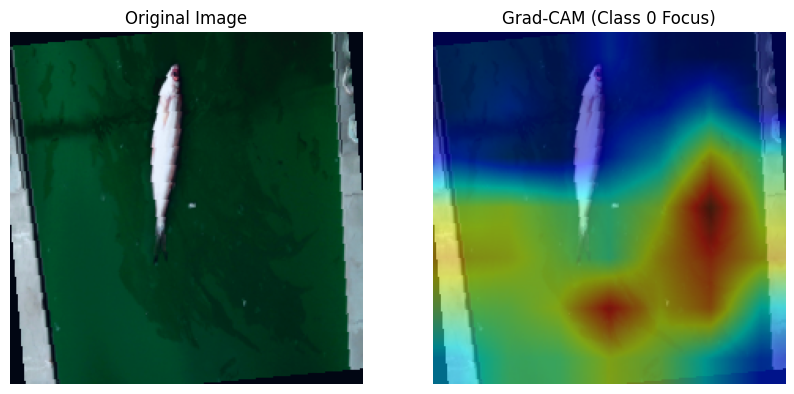

Generating Grad-CAM for Stream B...


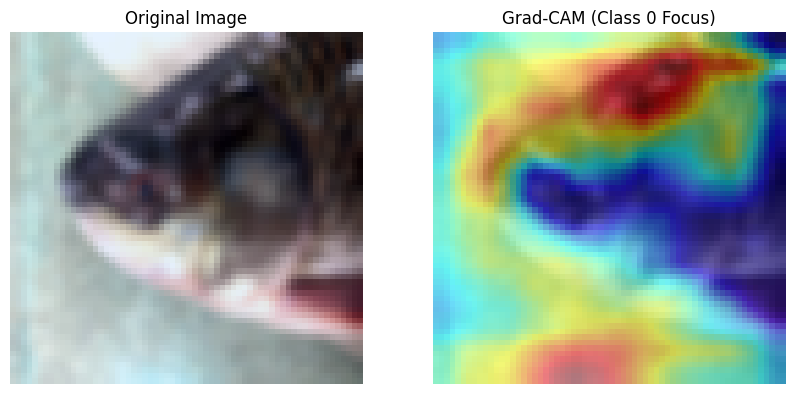

In [20]:
!pip install -q grad-cam
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def generate_gradcam(model, image_tensor, original_image, target_layer, class_idx):
    """
    Generates and plots a Grad-CAM heatmap over the original image.
    """
    model.eval()

    # FIX: Ensure the target layer allows gradients, even if frozen previously
    for param in target_layer.parameters():
        param.requires_grad = True

    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(class_idx)]

    # The forward pass now captures the necessary gradients
    grayscale_cam = cam(image_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    visualization = show_cam_on_image(original_image, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(visualization)
    axes[1].set_title(f"Grad-CAM (Class {class_idx} Focus)")
    axes[1].axis('off')
    plt.show()

# --- 1. Grad-CAM for Stream A (Whole Body) ---
print("Generating Grad-CAM for Stream A...")
dataiter_a = iter(val_loader_a)
images_a, labels_a = next(dataiter_a)
input_tensor_a = images_a[0].unsqueeze(0).to(device)
rgb_img_a = images_a[10].permute(1, 2, 0).cpu().numpy()
rgb_img_a = (rgb_img_a - rgb_img_a.min()) / (rgb_img_a.max() - rgb_img_a.min())
generate_gradcam(stream_a_model, input_tensor_a, rgb_img_a, stream_a_model.features[-1], class_idx=labels_a[0].item())

# --- 2. Grad-CAM for Stream B (Biomarkers) ---
print("Generating Grad-CAM for Stream B...")
dataiter_b = iter(test_loader)
images_b, labels_b = next(dataiter_b)
input_tensor_b = images_b[0].unsqueeze(0).to(device)
rgb_img_b = images_b[0].permute(1, 2, 0).cpu().numpy()
rgb_img_b = (rgb_img_b - rgb_img_b.min()) / (rgb_img_b.max() - rgb_img_b.min())
generate_gradcam(stream_b_model, input_tensor_b, rgb_img_b, stream_b_model.conv3, class_idx=labels_b[0].item())

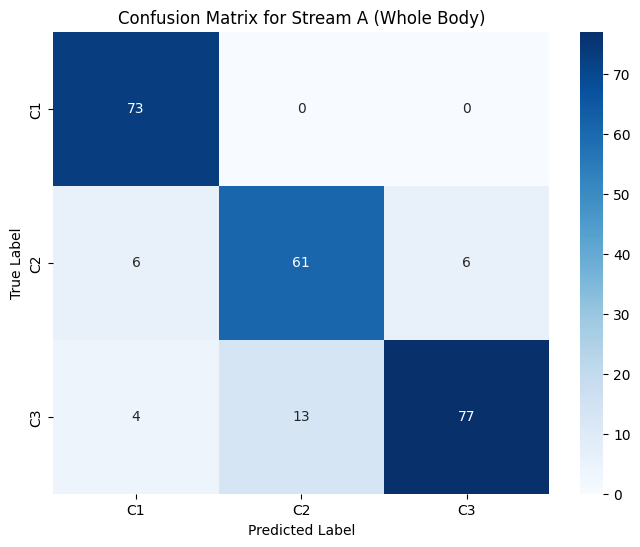

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Confusion Matrix for Stream A (Whole Body) ---

stream_a_model.eval() # Set model to evaluation mode
all_labels_a = []
all_predictions_a = []

with torch.no_grad():
    for inputs, labels in val_loader_a:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = stream_a_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_labels_a.extend(labels.cpu().numpy())
        all_predictions_a.extend(predicted.cpu().numpy())

# Get class names for Stream A
class_names_a = full_dataset_a.classes

# Calculate confusion matrix
cm_a = confusion_matrix(all_labels_a, all_predictions_a)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_a, yticklabels=class_names_a)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Stream A (Whole Body)')
plt.show()

Processing: /root/.cache/kagglehub/datasets/jiscecseaiml/fish-classification-dataset/versions/1/Testing/Nonfresh_Gills/IMG_7501.JPG
Anomaly detected (Nonfresh_Gills). Generating heatmap...


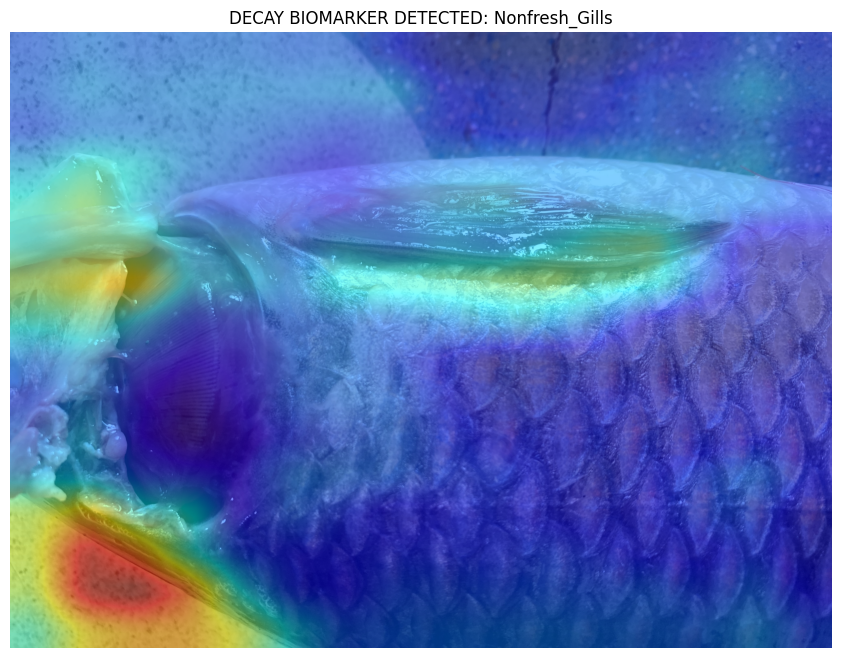

In [31]:
import PIL.Image
import numpy as np
import torch
import os
import cv2
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt

# 1. Select a random high-res image from the testing set
stream_b_test_dir = test_dir
all_test_images = []
for root, dirs, files in os.walk(stream_b_test_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            all_test_images.append(os.path.join(root, file))

if len(all_test_images) == 0:
    print(f"No images found in {stream_b_test_dir}.")
else:
    # Pick a sample
    sample_path = all_test_images[6]
    print(f"Processing: {sample_path}")
    original_pil_img = PIL.Image.open(sample_path).convert('RGB')
    img_np = np.array(original_pil_img).astype(np.float32) / 255.0

    # 2. Pre-process for the model
    preprocess = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = preprocess(original_pil_img).unsqueeze(0).to(device)

    # 3. Get model prediction
    stream_b_model.eval()
    with torch.no_grad():
        output = stream_b_model(input_tensor)
        pred_idx = torch.argmax(output).item()

    predicted_class = class_names[pred_idx]

    # 4. Conditional Visualization Logic
    # Only show Grad-CAM if the class is 'Nonfresh_Eyes' (2) or 'Nonfresh_Gills' (3)
    if "Nonfresh" in predicted_class:
        print(f"Anomaly detected ({predicted_class}). Generating heatmap...")
        for param in stream_b_model.conv3.parameters():
            param.requires_grad = True

        cam = GradCAM(model=stream_b_model, target_layers=[stream_b_model.conv3])
        targets = [ClassifierOutputTarget(pred_idx)]

        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
        grayscale_cam_high_res = cv2.resize(grayscale_cam, (img_np.shape[1], img_np.shape[0]))
        visualization = show_cam_on_image(img_np, grayscale_cam_high_res, use_rgb=True)

        plt.figure(figsize=(12, 8))
        plt.imshow(visualization)
        plt.title(f"DECAY BIOMARKER DETECTED: {predicted_class}")
    else:
        print(f"Biomarker is {predicted_class}. No heatmap required.")
        plt.figure(figsize=(12, 8))
        plt.imshow(img_np)
        plt.title(f"FRESH BIOMARKER: {predicted_class} (Clean Scan)")

    plt.axis('off')
    plt.show()

In [26]:
import torch
import os

# Define the Drive destination
drive_model_path = "/content/drive/MyDrive/freshscan_models"
os.makedirs(drive_model_path, exist_ok=True)

# 1. Save Stream A
stream_a_save_path = os.path.join(drive_model_path, "freshscan_stream_a_body.pth")
torch.save(stream_a_model.state_dict(), stream_a_save_path)

# 2. Save Stream B
stream_b_save_path = os.path.join(drive_model_path, "freshscan_stream_b_biomarker.pth")
torch.save(stream_b_model.state_dict(), stream_b_save_path)

print(f"Success! Both models saved to Drive:\n1. {stream_a_save_path}\n2. {stream_b_save_path}")

Success! Both models saved to Drive:
1. /content/drive/MyDrive/freshscan_models/freshscan_stream_a_body.pth
2. /content/drive/MyDrive/freshscan_models/freshscan_stream_b_biomarker.pth


In [27]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Re-initialize Stream A Architecture
def load_stream_a(path, device):
    model = models.mobilenet_v2(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, 3)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

# 2. Re-initialize Stream B Architecture
def load_stream_b(path, device):
    # Using the BiomarkerCNN class defined earlier
    model = BiomarkerCNN()
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load from Drive
drive_path = "/content/drive/MyDrive/freshscan_models"

try:
    stream_a_model = load_stream_a(os.path.join(drive_path, "freshscan_stream_a_body.pth"), device)
    stream_b_model = load_stream_b(os.path.join(drive_path, "freshscan_stream_b_biomarker.pth"), device)
    print("Models loaded successfully from Drive! Ready for inference.")
except Exception as e:
    print(f"Error loading models. Ensure Drive is mounted and files exist. Error: {e}")

Models loaded successfully from Drive! Ready for inference.


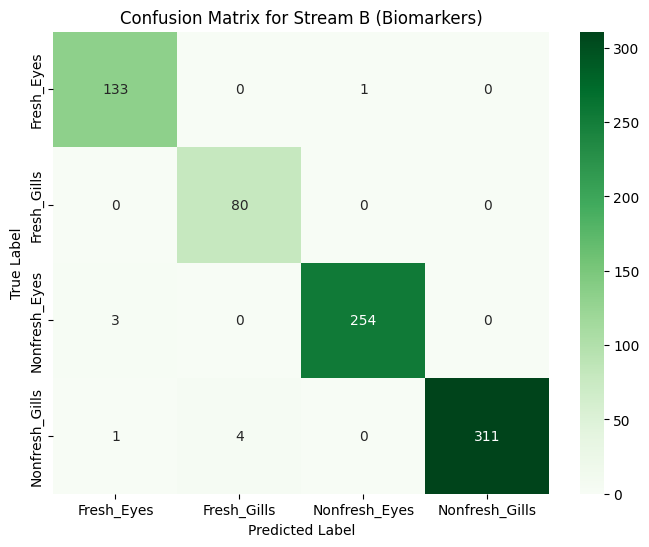

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Confusion Matrix for Stream B (Biomarkers) ---

stream_b_model.eval() # Set model to evaluation mode
all_labels_b = []
all_predictions_b = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = stream_b_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_labels_b.extend(labels.cpu().numpy())
        all_predictions_b.extend(predicted.cpu().numpy())

# Get class names for Stream B (already available as `class_names` from cell NfaUI_iioNy8)
class_names_b = class_names

# Calculate confusion matrix
cm_b = confusion_matrix(all_labels_b, all_predictions_b)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens', xticklabels=class_names_b, yticklabels=class_names_b)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Stream B (Biomarkers)')
plt.show()

In [4]:
import torch
import torch.nn.functional as F
import os

# 1. Verification and Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
drive_path = '/content/drive/MyDrive/freshscan_models'

def calculate_ece(model, loader, device, n_bins=10):
    model.eval()
    logits_list = []
    labels_list = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            logits = model(inputs)
            logits_list.append(logits)
            labels_list.append(labels)

    logits = torch.cat(logits_list).to(device)
    labels = torch.cat(labels_list).to(device)
    confidences, predictions = torch.max(F.softmax(logits, dim=1), 1)
    accuracies = predictions.eq(labels)

    ece = torch.zeros(1, device=device)
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)

    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = confidences.gt(bin_lower.item()) * confidences.le(bin_upper.item())
        prop_in_bin = in_bin.float().mean()
        if prop_in_bin.item() > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    return ece.item()

print('--- Confidence Calibration Results ---')

try:
    # Calculating for Stream A
    ece_a = calculate_ece(stream_a_model, val_loader_a, device)
    print(f'Stream A (Body) ECE: {ece_a:.4f}')

    # Calculating for Stream B
    ece_b = calculate_ece(stream_b_model, test_loader, device)
    print(f'Stream B (Biomarker) ECE: {ece_b:.4f}')

    if ece_a > 0.1 or ece_b > 0.1:
        print('\nSuggestion: ECE is relatively high. Consider applying Temperature Scaling.')
except NameError as e:
    print(f'Variables not found in memory: {e}')
    print('FIX: Please run cells YbUVxZKChy5y (Stream A Data), NfaUI_iioNy8 (Stream B Data), and 01b67fcc (Load Models) before running this cell.')

--- Confidence Calibration Results ---
Variables not found in memory: name 'stream_a_model' is not defined
FIX: Please run cells YbUVxZKChy5y (Stream A Data), NfaUI_iioNy8 (Stream B Data), and 01b67fcc (Load Models) before running this cell.


In [7]:
import kagglehub

print('Re-downloading datasets to restore cache...')
# Stream A Dataset
path_a = kagglehub.dataset_download('atcharachumpol/freshness-fish-dataset')
print('Stream A path:', path_a)

# Stream B Dataset
path_b = kagglehub.dataset_download('jiscecseaiml/fish-classification-dataset')
print('Stream B path:', path_b)

print('\nCache restored. You can now run the ECE calibration cell.')

Re-downloading datasets to restore cache...


100%|██████████| 405M/405M [00:02<00:00, 171MB/s]

Extracting files...


Stream A path: /root/.cache/kagglehub/datasets/atcharachumpol/freshness-fish-dataset/versions/1


100%|██████████| 9.26G/9.26G [01:36<00:00, 103MB/s]

Extracting files...


Stream B path: /root/.cache/kagglehub/datasets/jiscecseaiml/fish-classification-dataset/versions/1

Cache restored. You can now run the ECE calibration cell.


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

# 1. Re-initialize Environment
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
drive_path = '/content/drive/MyDrive/freshscan_models'

# 2. Path verification and Stream A Data Loading
dataset_a_path = "/root/.cache/kagglehub/datasets/atcharachumpol/freshness-fish-dataset/versions/1/Freshness Fish Dataset"
if not os.path.exists(dataset_a_path):
    # Fallback search if path is slightly different
    dataset_a_path = "/root/.cache/kagglehub/datasets/atcharachumpol/freshness-fish-dataset/versions/1"

transform_a = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset_a = datasets.ImageFolder(root=dataset_a_path, transform=transform_a)
train_count = int(0.8 * len(full_dataset_a))
val_count = len(full_dataset_a) - train_count
_, val_dataset_a = torch.utils.data.random_split(full_dataset_a, [train_count, val_count])
val_loader_a = DataLoader(val_dataset_a, batch_size=32, shuffle=False)

# 3. Stream B Data Loading
base_path_b = "/root/.cache/kagglehub/datasets/jiscecseaiml/fish-classification-dataset/versions/1"
test_dir_b = os.path.join(base_path_b, "Testing")

transform_b = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset_b = datasets.ImageFolder(root=test_dir_b, transform=transform_b)
test_loader = DataLoader(test_dataset_b, batch_size=32, shuffle=False)

# 4. Load Models and Calculate ECE
try:
    # Load Stream A
    stream_a_model = models.mobilenet_v2(weights=None)
    stream_a_model.classifier[1] = nn.Linear(stream_a_model.classifier[1].in_features, 3)
    stream_a_model.load_state_dict(torch.load(os.path.join(drive_path, "freshscan_stream_a_body.pth"), map_location=device))
    stream_a_model.to(device).eval()

    # Load Stream B
    class BiomarkerCNN(nn.Module):
        def __init__(self):
            super(BiomarkerCNN, self).__init__()
            self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
            self.bn1 = nn.BatchNorm2d(16)
            self.pool1 = nn.MaxPool2d(2, 2)
            self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
            self.bn2 = nn.BatchNorm2d(32)
            self.pool2 = nn.MaxPool2d(2, 2)
            self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm2d(64)
            self.pool3 = nn.MaxPool2d(2, 2)
            self.fc1 = nn.Linear(64 * 8 * 8, 128)
            self.dropout = nn.Dropout(0.5)
            self.fc2 = nn.Linear(128, 4)
        def forward(self, x):
            x = self.pool1(F.relu(self.bn1(self.conv1(x))))
            x = self.pool2(F.relu(self.bn2(self.conv2(x))))
            x = self.pool3(F.relu(self.bn3(self.conv3(x))))
            x = x.view(-1, 64 * 8 * 8)
            x = F.relu(self.fc1(x))
            x = self.dropout(x)
            return self.fc2(x)

    stream_b_model = BiomarkerCNN()
    stream_b_model.load_state_dict(torch.load(os.path.join(drive_path, "freshscan_stream_b_biomarker.pth"), map_location=device))
    stream_b_model.to(device).eval()

    print("Models and Data successfully re-initialized.")

    def get_ece(model, loader):
        logits_list, labels_list = [], []
        with torch.no_grad():
            for images, labels in loader:
                logits_list.append(model(images.to(device)))
                labels_list.append(labels.to(device))
        logits = torch.cat(logits_list)
        labels = torch.cat(labels_list)
        confidences, predictions = torch.max(F.softmax(logits, dim=1), 1)
        accuracies = predictions.eq(labels)
        ece = torch.zeros(1, device=device)
        bin_boundaries = torch.linspace(0, 1, 11)
        for bl, bu in zip(bin_boundaries[:-1], bin_boundaries[1:]):
            in_bin = confidences.gt(bl.item()) * confidences.le(bu.item())
            prop = in_bin.float().mean()
            if prop > 0:
                acc = accuracies[in_bin].float().mean()
                conf = confidences[in_bin].mean()
                ece += torch.abs(conf - acc) * prop
        return ece.item()

    print(f"Stream A (Body) ECE: {get_ece(stream_a_model, val_loader_a):.4f}")
    print(f"Stream B (Biomarker) ECE: {get_ece(stream_b_model, test_loader):.4f}")

except Exception as e:
    print(f"Failure: {e}")

Models and Data successfully re-initialized.
Stream A (Body) ECE: 0.0938
Stream B (Biomarker) ECE: 0.0121


In [10]:
import torch
import torch.nn as nn
from torch.optim import LBFGS
import torch.nn.functional as F

class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super(ModelWithTemperature, self).__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, input):
        logits = self.model(input)
        return self.temperature_scale(logits)

    def temperature_scale(self, logits):
        return logits / self.temperature

def set_temperature(valid_loader, model, device):
    model.eval()
    nll_criterion = nn.CrossEntropyLoss().to(device)

    # Helper to calculate ECE directly from tensors to avoid signature mismatch
    def calculate_ece_tensors(logits, labels, n_bins=10):
        confidences, predictions = torch.max(F.softmax(logits, dim=1), 1)
        accuracies = predictions.eq(labels)
        ece = torch.zeros(1, device=logits.device)
        bin_boundaries = torch.linspace(0, 1, n_bins + 1)
        for bl, bu in zip(bin_boundaries[:-1], bin_boundaries[1:]):
            in_bin = confidences.gt(bl.item()) * confidences.le(bu.item())
            prop = in_bin.float().mean()
            if prop > 0:
                acc = accuracies[in_bin].float().mean()
                conf = confidences[in_bin].mean()
                ece += torch.abs(conf - acc) * prop
        return ece.item()

    logits_list = []
    labels_list = []
    with torch.no_grad():
        for inputs, labels in valid_loader:
            logits_list.append(model(inputs.to(device)))
            labels_list.append(labels.to(device))

    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    print(f'ECE before temperature scaling: {calculate_ece_tensors(logits, labels):.4f}')

    scaled_model = ModelWithTemperature(model).to(device)
    optimizer = LBFGS([scaled_model.temperature], lr=0.01, max_iter=50)

    def eval_loop():
        optimizer.zero_grad()
        loss = nll_criterion(scaled_model.temperature_scale(logits), labels)
        loss.backward()
        return loss

    optimizer.step(eval_loop)

    after_ece = calculate_ece_tensors(scaled_model.temperature_scale(logits), labels)
    print(f'Optimal Temperature (T): {scaled_model.temperature.item():.4f}')
    print(f'ECE after temperature scaling: {after_ece:.4f}')

    return scaled_model

# Run calibration for Stream A
stream_a_calibrated = set_temperature(val_loader_a, stream_a_model, device)

ECE before temperature scaling: 0.0938
Optimal Temperature (T): 1.3975
ECE after temperature scaling: 0.1459


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 28.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
--- Testing Nonfresh Eyes ---
Testing Nonfresh_Eyes on: /root/.cache/kagglehub/datasets/jiscecseaiml/fish-classification-dataset/versions/1/Testing/Nonfresh_Eyes/IMG_6897.JPG


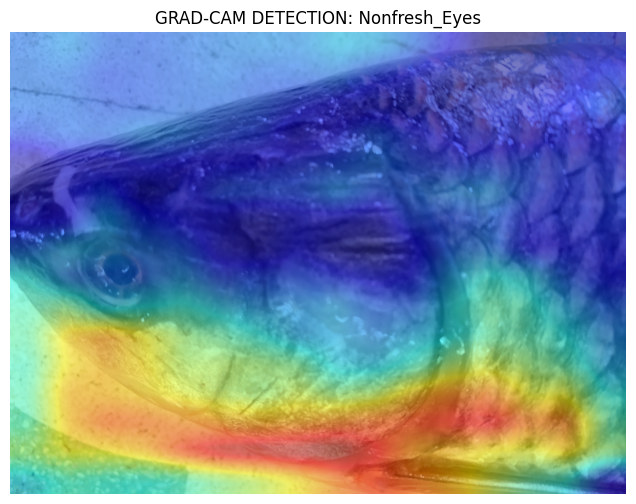


--- Testing Nonfresh Gills ---
Testing Nonfresh_Gills on: /root/.cache/kagglehub/datasets/jiscecseaiml/fish-classification-dataset/versions/1/Testing/Nonfresh_Gills/IMG_7558.JPG


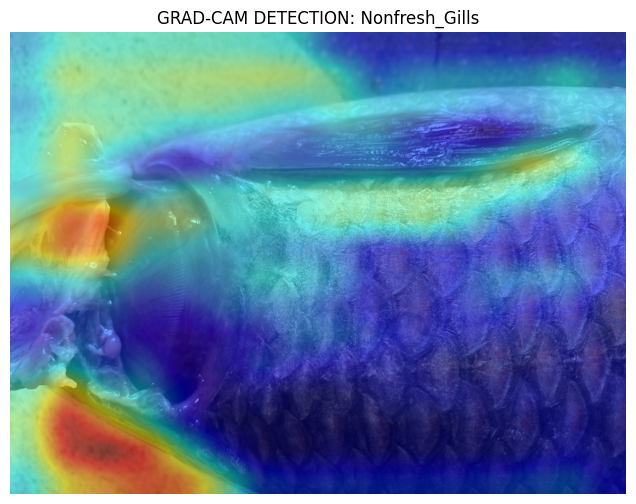

In [12]:
!pip install -q grad-cam
import random
import PIL.Image
import numpy as np
import torch
import cv2
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt

def test_biomarker_anomaly(target_class_name):
    # 1. Find images for the specific class
    class_idx = test_dataset_b.class_to_idx[target_class_name]
    indices = [i for i, (path, label) in enumerate(test_dataset_b.imgs) if label == class_idx]

    if not indices:
        print(f"No images found for {target_class_name}")
        return

    sample_idx = random.choice(indices)
    path, _ = test_dataset_b.imgs[sample_idx]
    print(f"Testing {target_class_name} on: {path}")

    # 2. Load and Pre-process
    original_pil_img = PIL.Image.open(path).convert('RGB')
    img_np = np.array(original_pil_img).astype(np.float32) / 255.0

    preprocess = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = preprocess(original_pil_img).unsqueeze(0).to(device)

    # 3. Generate Grad-CAM
    stream_b_model.eval()
    # Ensure gradients are enabled for the target layer
    for param in stream_b_model.conv3.parameters():
        param.requires_grad = True

    cam = GradCAM(model=stream_b_model, target_layers=[stream_b_model.conv3])
    targets = [ClassifierOutputTarget(class_idx)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    grayscale_cam_high_res = cv2.resize(grayscale_cam, (img_np.shape[1], img_np.shape[0]))
    visualization = show_cam_on_image(img_np, grayscale_cam_high_res, use_rgb=True)

    # 4. Display
    plt.figure(figsize=(10, 6))
    plt.imshow(visualization)
    plt.title(f"GRAD-CAM DETECTION: {target_class_name}")
    plt.axis('off')
    plt.show()

# Run tests for both requested anomaly classes
print("--- Testing Nonfresh Eyes ---")
test_biomarker_anomaly('Nonfresh_Eyes')

print("\n--- Testing Nonfresh Gills ---")
test_biomarker_anomaly('Nonfresh_Gills')
